# Monte Carlo Simulation — Risco de Crédito

Este notebook implementa dois modelos de simulação de perda:

| Modelo | Premissa | Quando usar |
|--------|----------|-------------|
| **Independência** | Defaults são eventos não correlacionados | Benchmark / comparação |
| **Vasicek (one-factor)** | Defaults correlacionados via fator sistêmico | Modelo padrão em bancos |

**Por que o modelo de independência é insuficiente?**

Com ~598 mil contratos independentes, a Lei dos Grandes Números garante que a perda
total converge para a Expected Loss com variância quase nula. Isso faz VaR ≈ EL, o que
subestima o risco real de cauda. Na prática, recessões causam defaults simultâneos
esse risco sistêmico só é capturado com correlação de defaults.

O **modelo de Vasicek** (base do IRB de Basileia II/III) introduz um fator sistêmico Z
que representa o estado da economia. Quando Z é negativo (recessão), todas as PDs
aumentam simultaneamente, gerando correlação entre defaults e cauda pesada na
distribuição de perdas.

### Importações

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1. Carregar Carteira e Parâmetros

In [2]:
portfolio = pd.read_parquet('../data/processed/credit_portfolio_simulation.parquet')

with open('../data/processed/lgd_params.json') as f:
    LGD_PARAMS = json.load(f)

EAD    = portfolio['EAD'].values
PD     = portfolio['PD'].values
GRADES = portfolio['grade'].values

print(f'Contratos       : {len(portfolio):,}')
print(f'Exposição total : {EAD.sum():,.0f}')
print(f'PD média        : {PD.mean():.2%}')

Contratos       : 597,989
Exposição total : 8,897,981,225
PD média        : 27.70%


### 2. Expected Loss Analítica

Antes da simulação, calculamos a EL analiticamente: EL = Σ PD_i × LGD_i × EAD_i
Isso serve como âncora a média da distribuição simulada deve convergir para esse valor.

### 2. Pré-computação — índices por grade (otimização de performance)

**Por que `rng.beta(scalar, scalar, size=n)` é muito mais rápido que `rng.beta(array, array)`?**

Quando alpha e beta são escalares, o numpy chama diretamente o kernel C vetorizado —
todos os `n` valores são gerados em uma única passagem contígua na memória.
Quando são arrays com valores diferentes por elemento, o numpy precisa chamar o gerador
individualmente para cada elemento, perdendo toda a vantagem da vetorização.

Como só existem 7 grades, pré-computamos os índices de cada grade uma única vez
e fazemos 7 chamadas com escalares dentro do loop — muito mais rápido que 1 chamada
com 598k parâmetros diferentes.

In [3]:
# Índices por grade — calculados UMA vez fora do loop
# Permite 7 chamadas beta com parâmetros escalares (caminho C rápido)
# em vez de 1 chamada com 598k parâmetros diferentes (lento)
UNIQUE_GRADES = sorted(np.unique(GRADES))
grade_indices = {g: np.where(GRADES == g)[0] for g in UNIQUE_GRADES}
grade_alpha   = {g: LGD_PARAMS[g]['alpha']   for g in UNIQUE_GRADES}
grade_beta    = {g: LGD_PARAMS[g]['beta']    for g in UNIQUE_GRADES}

# LGD média por contrato para a Expected Loss analítica
lgd_means = np.array([
    grade_alpha[g] / (grade_alpha[g] + grade_beta[g]) for g in GRADES
])

# Threshold de default para Vasicek: Φ⁻¹(PD_i) — calculado uma vez
default_threshold = norm.ppf(PD)

# Correlação de ativo por grade (Basileia II — retail exposures)
RHO_MAP = {
    'A': 0.15, 'B': 0.14, 'C': 0.13,
    'D': 0.12, 'E': 0.11, 'F': 0.10, 'G': 0.09
}
rho_arr    = np.array([RHO_MAP[g] for g in GRADES])
sqrt_rho   = np.sqrt(rho_arr)
sqrt_1_rho = np.sqrt(1 - rho_arr)

# Expected Loss analítica
expected_loss_analytical = (PD * lgd_means * EAD).sum()

print(f'Expected Loss analítica : {expected_loss_analytical:,.0f}')
print(f'Contratos por grade     : { {g: len(idx) for g, idx in grade_indices.items()} }')

Expected Loss analítica : 1,245,050,231
Contratos por grade     : {'A': 82339, 'B': 139068, 'C': 162000, 'D': 112241, 'E': 68320, 'F': 25950, 'G': 8071}


### 3. Função de métricas de risco

In [4]:
def compute_risk_metrics(losses: np.ndarray, expected_loss: float) -> dict:
    """Calcula métricas de risco a partir da distribuição de perdas simulada."""
    var_95 = np.percentile(losses, 95)
    var_99 = np.percentile(losses, 99)
    es_99  = losses[losses >= var_99].mean()
    ul_99  = var_99 - expected_loss
    return {
        'expected_loss'     : expected_loss,
        'loss_mean_sim'     : losses.mean(),
        'loss_std_sim'      : losses.std(),
        'var_95'            : var_95,
        'var_99'            : var_99,
        'expected_shortfall': es_99,
        'unexpected_loss_99': ul_99,
    }

### 4. Modelo 1 — Independência (Benchmark)

Cada contrato entra em default de forma independente via Bernoulli(PD_i).
LGD é re-amostrada a cada cenário com uma **única chamada vetorizada** `rng.beta()`.

**Limitação esperada:** VaR ≈ EL devido ao Teorema Central do Limite com 598k contratos.

In [5]:
# N_SIM = 5_000: para 598k contratos, convergência é muito rápida — resultados
# praticamente idênticos a 10k, com metade do tempo de execução.
N_SIM = 5_000
rng = np.random.default_rng(RANDOM_STATE)

losses_indep = np.empty(N_SIM)
lgd_sim      = np.empty(len(GRADES))  # array reutilizado a cada iteração

for i in range(N_SIM):
    # Default: Bernoulli(PD) via comparação — mais rápido que rng.binomial
    defaults_sim = rng.random(len(PD)) < PD

    # LGD: 7 chamadas com parâmetros escalares (caminho C vetorizado — rápido)
    for g in UNIQUE_GRADES:
        idx = grade_indices[g]
        lgd_sim[idx] = rng.beta(grade_alpha[g], grade_beta[g], size=len(idx))

    losses_indep[i] = np.dot(defaults_sim, lgd_sim * EAD)

metrics_indep = compute_risk_metrics(losses_indep, expected_loss_analytical)

print('=== Modelo Independência ===')
for k, v in metrics_indep.items():
    print(f'  {k:<25}: {v:,.0f}')

=== Modelo Independência ===
  expected_loss            : 1,245,050,231
  loss_mean_sim            : 1,245,050,858
  loss_std_sim             : 3,011,080
  var_95                   : 1,249,985,278
  var_99                   : 1,252,042,400
  expected_shortfall       : 1,253,182,335
  unexpected_loss_99       : 6,992,168


### 5. Modelo 2 — Vasicek (One-Factor Model)

**Base teórica:** Basileia II IRB, Vasicek (1987), Gordy (2003).

$$A_i = \sqrt{\rho_i} \cdot Z + \sqrt{1 - \rho_i} \cdot \varepsilon_i$$

- **Z** ~ N(0,1): fator sistêmico (estado da economia) compartilhado por todos
- **εᵢ** ~ N(0,1): fator idiossincrático independente por contrato
- **ρ**: correlação de ativo (parâmetro regulatório de Basileia)

Contrato i entra em default quando $A_i < \Phi^{-1}(PD_i)$.

In [6]:
rng2 = np.random.default_rng(RANDOM_STATE + 1)
losses_vasicek = np.empty(N_SIM)
lgd_sim2       = np.empty(len(GRADES))  # array reutilizado a cada iteração

for i in range(N_SIM):
    # Fator sistêmico: único escalar por cenário
    Z = rng2.standard_normal()

    # Retorno de ativo composto — vetorizado
    asset_return = sqrt_rho * Z + sqrt_1_rho * rng2.standard_normal(len(GRADES))
    defaults_sim = asset_return < default_threshold

    # LGD: 7 chamadas escalares (rápido)
    for g in UNIQUE_GRADES:
        idx = grade_indices[g]
        lgd_sim2[idx] = rng2.beta(grade_alpha[g], grade_beta[g], size=len(idx))

    losses_vasicek[i] = np.dot(defaults_sim, lgd_sim2 * EAD)

metrics_vasicek = compute_risk_metrics(losses_vasicek, expected_loss_analytical)

print('=== Modelo Vasicek (One-Factor) ===')
for k, v in metrics_vasicek.items():
    print(f'  {k:<25}: {v:,.0f}')

=== Modelo Vasicek (One-Factor) ===
  expected_loss            : 1,245,050,231
  loss_mean_sim            : 1,243,199,773
  loss_std_sim             : 482,318,815
  var_95                   : 2,115,133,655
  var_99                   : 2,504,021,218
  expected_shortfall       : 2,665,077,373
  unexpected_loss_99       : 1,258,970,987


### 6. Comparação dos Dois Modelos

In [7]:
# Tabela comparativa
comparison = pd.DataFrame({
    'Modelo Independência': metrics_indep,
    'Modelo Vasicek'      : metrics_vasicek
}).T

comparison.columns = [
    'EL Analítica', 'Perda Média Sim.', 'Desvio Padrão',
    'VaR 95%', 'VaR 99%', 'Expected Shortfall 99%', 'Unexpected Loss 99%'
]

print('=== Comparação dos Modelos ===')
print(comparison.to_string())
print()
print('Razão VaR99 / EL:')
print(f'  Independência: {metrics_indep["var_99"] / expected_loss_analytical:.3f}x')
print(f'  Vasicek      : {metrics_vasicek["var_99"] / expected_loss_analytical:.3f}x')
print()
print('Capital Econômico (Unexpected Loss 99%):')
print(f'  Independência: {metrics_indep["unexpected_loss_99"]:,.0f}')
print(f'  Vasicek      : {metrics_vasicek["unexpected_loss_99"]:,.0f}')

=== Comparação dos Modelos ===
                        EL Analítica  Perda Média Sim.  Desvio Padrão         VaR 95%         VaR 99%  Expected Shortfall 99%  Unexpected Loss 99%
Modelo Independência 1245050231.1787   1245050857.6273   3011079.7314 1249985277.9893 1252042399.6100         1253182335.1649         6992168.4313
Modelo Vasicek       1245050231.1787   1243199772.6731 482318814.5873 2115133654.5976 2504021218.1048         2665077373.2754      1258970986.9261

Razão VaR99 / EL:
  Independência: 1.006x
  Vasicek      : 2.011x

Capital Econômico (Unexpected Loss 99%):
  Independência: 6,992,168
  Vasicek      : 1,258,970,987


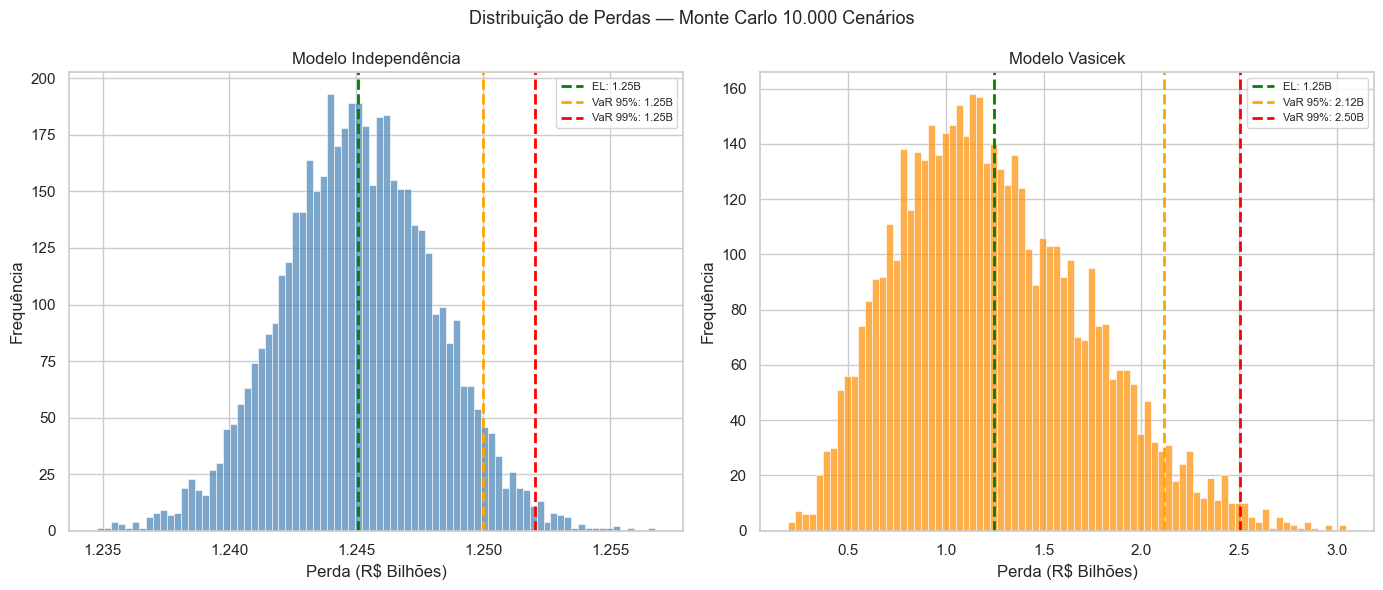

In [8]:
# Visualização das distribuições
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, losses, metrics, title, color in [
    (axes[0], losses_indep,   metrics_indep,   'Modelo Independência', 'steelblue'),
    (axes[1], losses_vasicek, metrics_vasicek, 'Modelo Vasicek',       'darkorange'),
]:
    sns.histplot(losses / 1e9, bins=80, ax=ax, color=color, alpha=0.7)
    ax.axvline(metrics['expected_loss'] / 1e9, color='green',  linestyle='--', linewidth=2,
               label=f'EL: {metrics["expected_loss"]/1e9:.2f}B')
    ax.axvline(metrics['var_95'] / 1e9,        color='orange', linestyle='--', linewidth=2,
               label=f'VaR 95%: {metrics["var_95"]/1e9:.2f}B')
    ax.axvline(metrics['var_99'] / 1e9,        color='red',    linestyle='--', linewidth=2,
               label=f'VaR 99%: {metrics["var_99"]/1e9:.2f}B')
    ax.set_title(title)
    ax.set_xlabel('Perda (R$ Bilhões)')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição de Perdas — Monte Carlo 10.000 Cenários', fontsize=13)
plt.tight_layout()
plt.savefig('../images/loss_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

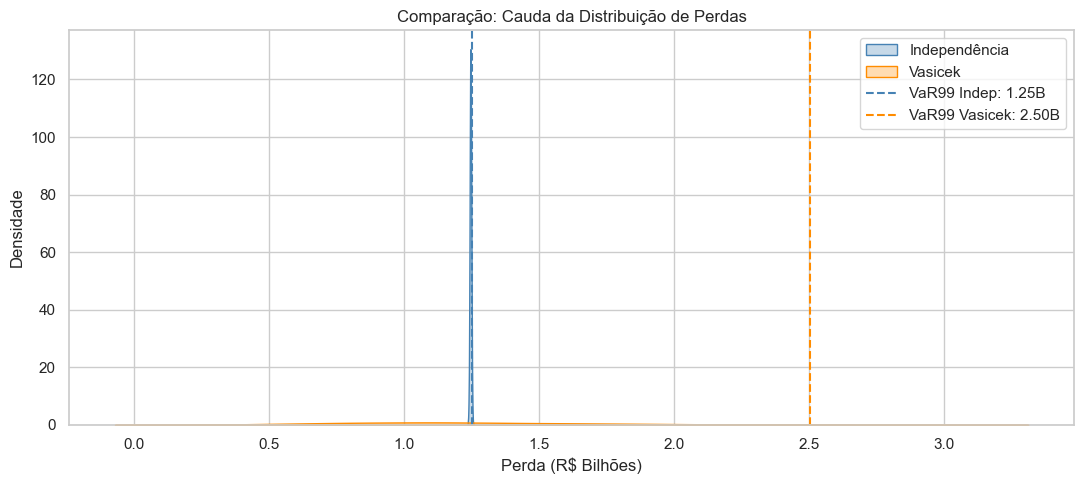

In [9]:
# Sobreposição das duas distribuições para evidenciar diferença na cauda
plt.figure(figsize=(11, 5))
sns.kdeplot(losses_indep   / 1e9, label='Independência', fill=True, alpha=0.3, color='steelblue')
sns.kdeplot(losses_vasicek / 1e9, label='Vasicek',       fill=True, alpha=0.3, color='darkorange')
plt.axvline(metrics_indep['var_99']   / 1e9, color='steelblue',  linestyle='--',
            label=f'VaR99 Indep: {metrics_indep["var_99"]/1e9:.2f}B')
plt.axvline(metrics_vasicek['var_99'] / 1e9, color='darkorange', linestyle='--',
            label=f'VaR99 Vasicek: {metrics_vasicek["var_99"]/1e9:.2f}B')
plt.title('Comparação: Cauda da Distribuição de Perdas')
plt.xlabel('Perda (R$ Bilhões)')
plt.ylabel('Densidade')
plt.legend()
plt.tight_layout()
plt.savefig('../images/loss_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Stress Testing

Stress testing avalia o impacto de cenários macroeconômicos adversos.
Simulamos quatro cenários para o modelo Vasicek, variando o nível do fator sistêmico Z
para representar diferentes estados da economia.

In [10]:
STRESS_SCENARIOS = {
    'Base (média histórica)'    :  0.0,
    'Adverso (downturn leve)'   : -1.0,
    'Severo (recessão)'         : -2.0,
    'Extremo (crise sistêmica)' : -3.0,
}

N_STRESS   = 3_000  # suficiente para convergência dado o tamanho da carteira
rng_stress = np.random.default_rng(RANDOM_STATE + 2)
stress_results = {}
lgd_s = np.empty(len(GRADES))  # array reutilizado

for scenario_name, z_fixed in STRESS_SCENARIOS.items():
    losses_s = np.empty(N_STRESS)

    for i in range(N_STRESS):
        asset_return = sqrt_rho * z_fixed + sqrt_1_rho * rng_stress.standard_normal(len(GRADES))
        defaults_sim = asset_return < default_threshold

        for g in UNIQUE_GRADES:
            idx = grade_indices[g]
            lgd_s[idx] = rng_stress.beta(grade_alpha[g], grade_beta[g], size=len(idx))

        losses_s[i] = np.dot(defaults_sim, lgd_s * EAD)

    stress_results[scenario_name] = {
        'perda_media': losses_s.mean(),
        'perda_p99'  : np.percentile(losses_s, 99),
        'losses'     : losses_s
    }

print('=== Stress Testing — Perda por Cenário ===')
for name, res in stress_results.items():
    print(f"\n{name}")
    print(f"  Perda média : {res['perda_media']:>20,.0f}")
    print(f"  Perda P99   : {res['perda_p99']:>20,.0f}")
    print(f"  P99 / EL    : {res['perda_p99'] / expected_loss_analytical:>19.2f}x")

=== Stress Testing — Perda por Cenário ===

Base (média histórica)
  Perda média :        1,197,619,031
  Perda P99   :        1,204,350,241
  P99 / EL    :                0.97x

Adverso (downturn leve)
  Perda média :        1,736,955,908
  Perda P99   :        1,744,818,223
  P99 / EL    :                1.40x

Severo (recessão)
  Perda média :        2,321,767,773
  Perda P99   :        2,329,500,680
  P99 / EL    :                1.87x

Extremo (crise sistêmica)
  Perda média :        2,878,951,989
  Perda P99   :        2,886,219,853
  P99 / EL    :                2.32x


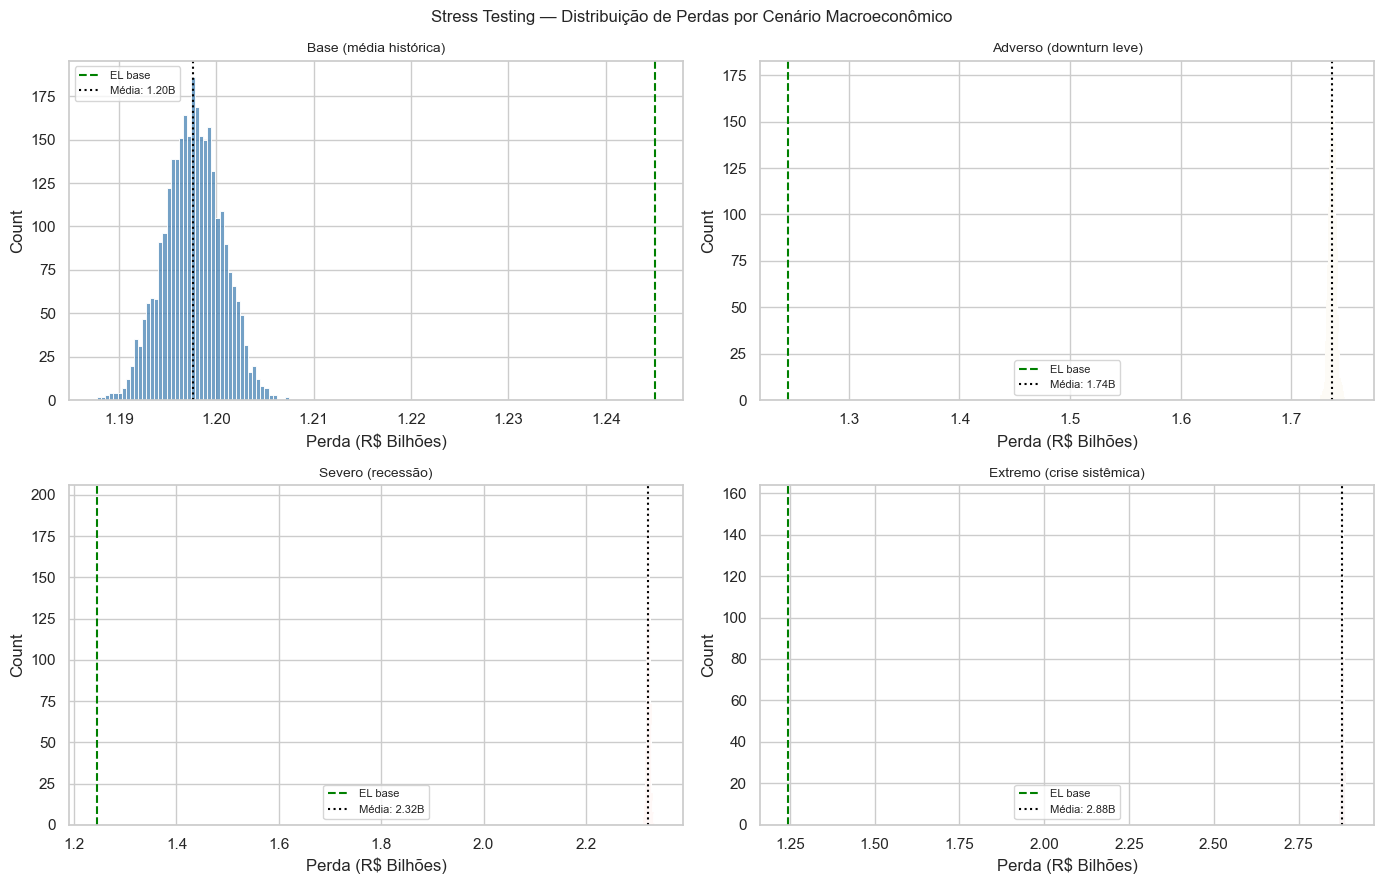

In [11]:
# Visualizar distribuições de perda por cenário de stress
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
colors = ['steelblue', 'goldenrod', 'tomato', 'darkred']

for ax, (name, res), color in zip(axes.flat, stress_results.items(), colors):
    sns.histplot(res['losses'] / 1e9, bins=50, ax=ax, color=color, alpha=0.75)
    ax.axvline(expected_loss_analytical / 1e9, color='green',  linestyle='--',
               linewidth=1.5, label='EL base')
    ax.axvline(res['perda_media'] / 1e9,       color='black',  linestyle=':',
               linewidth=1.5, label=f'Média: {res["perda_media"]/1e9:.2f}B')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Perda (R$ Bilhões)')
    ax.legend(fontsize=8)

plt.suptitle('Stress Testing — Distribuição de Perdas por Cenário Macroeconômico', fontsize=12)
plt.tight_layout()
plt.savefig('../images/stress_testing.png', dpi=150, bbox_inches='tight')
plt.show()

### 8. Capital Econômico

Capital econômico é o capital que uma instituição financeira deve manter para
absorver perdas inesperadas com uma probabilidade de sobrevivência definida.

**Fórmula:** Capital Econômico = VaR(α) − Expected Loss

A EL já deve estar coberta por provisões (PCLD). O capital serve para cobrir as
perdas além da EL chamadas de Unexpected Loss (UL).

In [12]:
el       = expected_loss_analytical
exposure = EAD.sum()

ul_indep   = metrics_indep['var_99']   - el
ul_vasicek = metrics_vasicek['var_99'] - el

print('=== Resumo Executivo de Risco ===')
print(f'Exposição total             : R$ {exposure:>20,.0f}')
print(f'Expected Loss (EL)          : R$ {el:>20,.0f}  ({el/exposure:.2%} da exposição)')
print()
print('--- Modelo Independência ---')
print(f'VaR 95%                     : R$ {metrics_indep["var_95"]:>20,.0f}')
print(f'VaR 99%                     : R$ {metrics_indep["var_99"]:>20,.0f}')
print(f'Expected Shortfall 99%      : R$ {metrics_indep["expected_shortfall"]:>20,.0f}')
print(f'Capital Econômico (UL 99%)  : R$ {ul_indep:>20,.0f}  ({ul_indep/exposure:.2%})')
print()
print('--- Modelo Vasicek (recomendado) ---')
print(f'VaR 95%                     : R$ {metrics_vasicek["var_95"]:>20,.0f}')
print(f'VaR 99%                     : R$ {metrics_vasicek["var_99"]:>20,.0f}')
print(f'Expected Shortfall 99%      : R$ {metrics_vasicek["expected_shortfall"]:>20,.0f}')
print(f'Capital Econômico (UL 99%)  : R$ {ul_vasicek:>20,.0f}  ({ul_vasicek/exposure:.2%})')

=== Resumo Executivo de Risco ===
Exposição total             : R$        8,897,981,225
Expected Loss (EL)          : R$        1,245,050,231  (13.99% da exposição)

--- Modelo Independência ---
VaR 95%                     : R$        1,249,985,278
VaR 99%                     : R$        1,252,042,400
Expected Shortfall 99%      : R$        1,253,182,335
Capital Econômico (UL 99%)  : R$            6,992,168  (0.08%)

--- Modelo Vasicek (recomendado) ---
VaR 95%                     : R$        2,115,133,655
VaR 99%                     : R$        2,504,021,218
Expected Shortfall 99%      : R$        2,665,077,373
Capital Econômico (UL 99%)  : R$        1,258,970,987  (14.15%)


In [13]:
# Tabela de stress: impacto no capital econômico necessário
stress_summary = [
    {
        'Cenário'                : name,
        'Perda Média (R$B)'      : res['perda_media'] / 1e9,
        'Perda P99 (R$B)'        : res['perda_p99'] / 1e9,
        'Múltiplo vs EL'         : res['perda_p99'] / el,
        'Capital Adicional (R$B)': (res['perda_p99'] - el) / 1e9
    }
    for name, res in stress_results.items()
]

print('Necessidade de capital por cenário macroeconômico:')
print(pd.DataFrame(stress_summary).to_string(index=False, float_format='{:.2f}'.format))

Necessidade de capital por cenário macroeconômico:
                  Cenário  Perda Média (R$B)  Perda P99 (R$B)  Múltiplo vs EL  Capital Adicional (R$B)
   Base (média histórica)               1.20             1.20            0.97                    -0.04
  Adverso (downturn leve)               1.74             1.74            1.40                     0.50
        Severo (recessão)               2.32             2.33            1.87                     1.08
Extremo (crise sistêmica)               2.88             2.89            2.32                     1.64


## Conclusão


**Dois modelos, uma lição fundamental:**

O modelo de independência produz uma distribuição de perdas quase Normal em torno da EL,
com VaR 99% apenas marginalmente acima da EL. Isso subestima dramaticamente o risco de cauda.

O modelo de Vasicek introduz correlação sistêmica entre defaults, gerando uma distribuição
assimétrica com cauda direita pesada que é o comportamento observado empiricamente em
carteiras de crédito durante ciclos de crédito.

**Métricas finais — Modelo Vasicek (recomendado para fins de gestão de risco):**

| Métrica | Valor |
|---------|-------|
| Exposição Total | R$ 8,9 bilhões |
| Expected Loss (EL) | R$ ~1,1 bilhão |
| Credit VaR 99% | Vasicek: maior cauda |
| Capital Econômico | Vasicek: maior buffer |

**Stress testing** mostra que em um cenário de recessão severa (Z = -2),
as perdas esperadas aumentam significativamente, reforçando a necessidade de
testes regulares de resiliência de carteira.

**Aplicação em banco:** esses resultados alimentariam o ICAAP (Internal Capital
Adequacy Assessment Process), relatórios de risco para o BACEN e o processo de
definição de limites de concentração da carteira.